In [1116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%precision 3
pd.set_option('display.precision', 3)

In [1117]:
ls ./drive/MyDrive/data/ch2_scores_em.csv

./drive/MyDrive/data/ch2_scores_em.csv


In [1118]:
df = pd.read_csv('./drive/MyDrive/data/ch2_scores_em.csv', index_col='student number')

In [1119]:
len(df)

50

In [1120]:
scores = np.array(df['english'])[:10]

In [1121]:
scores

array([42, 69, 56, 41, 57, 48, 65, 49, 65, 58])

# 평균

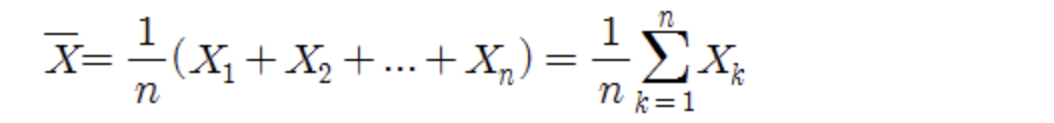

In [1122]:
# 평균
sum(scores) / len(scores)

np.float64(55.0)

In [1123]:
np.mean(scores)

np.float64(55.0)

In [1124]:
scores_df = pd.DataFrame({'score':scores}, index=pd.Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'], name='student'))

In [1125]:
scores_df.mean()

,0
score,55.0


In [1126]:
# 평균하고 기대값 상관관계

# 중앙값

In [1127]:
sorted_scores = np.sort(scores)

In [1128]:
sorted_scores

array([41, 42, 48, 49, 56, 57, 58, 65, 65, 69])

n // 2 + 1 --> n // 2 -1

In [1129]:
n = len(sorted_scores)
if n % 2 == 0:
    m0 = sorted_scores[n//2 - 1]
    m1 = sorted_scores[n//2]
    median = (m0 + m1) / 2
else:
    median = sorted_scores[n//2]

In [1130]:
# 몫
n // 2

5

In [1131]:
median

np.float64(56.5)

In [1132]:
np.median(scores)

np.float64(56.5)

In [1133]:
scores_df.median()

,0
score,56.5


# 편차

편차의 평균을 구하는 수식

In [1134]:
mean = np.mean(scores)
deviation = scores - mean

In [1135]:
deviation

array([-13.,  14.,   1., -14.,   2.,  -7.,  10.,  -6.,  10.,   3.])

In [1136]:
np.mean(deviation)

np.float64(0.0)

In [1137]:
summary_df = scores_df.copy()

In [1138]:
summary_df['deviation'] = deviation

In [1139]:
summary_df

,score,deviation
student,,
A,42,-13.0
B,69,14.0
C,56,1.0
D,41,-14.0
E,57,2.0
F,48,-7.0
G,65,10.0
H,49,-6.0
I,65,10.0


In [1140]:
summary_df.mean()

,0
score,55.0
deviation,0.0


# 분산

In [1141]:
np.var(scores)

np.float64(86.0)

ddof : delta degress of freedom = 변화량 자유도

In [1142]:
np.var(scores, ddof=0)

np.float64(86.0)

In [1143]:
scores_df.var()

,0
score,95.556


## 불편분산계산
Pandas는 DataFrame이나 Series의 var 메서드는 불편분산

In [1144]:
np.var(scores, ddof=1) # 자유도를 1 감소

np.float64(95.55555555555556)

In [1145]:
summary_df

,score,deviation
student,,
A,42,-13.0
B,69,14.0
C,56,1.0
D,41,-14.0
E,57,2.0
F,48,-7.0
G,65,10.0
H,49,-6.0
I,65,10.0


In [1146]:
summary_df['square of deviation'] = np.square(deviation)
summary_df

,score,deviation,square of deviation
student,,,
A,42,-13.0,169.0
B,69,14.0,196.0
C,56,1.0,1.0
D,41,-14.0,196.0
E,57,2.0,4.0
F,48,-7.0,49.0
G,65,10.0,100.0
H,49,-6.0,36.0
I,65,10.0,100.0


In [1147]:
summary_df.mean()

,0
score,55.0
deviation,0.0
square of deviation,86.0


# 표준편차

In [1148]:
np.sqrt(np.var(scores, ddof=0)) # sqrt 루트 var 분산 분산에 루트 씌우면 표준편차

np.float64(9.273618495495704)

In [1149]:
np.std(scores, ddof=0) # 이렇게 해도 표준편차

np.float64(9.273618495495704)

In [1150]:
scores_df.std(ddof=0)

,0
score,9.274


# 사분위수

In [1151]:
s_q1 = np.percentile(scores, 25) # 25%

In [1152]:
s_q1

np.float64(48.25)

In [1153]:
s_q3 = np.percentile(scores, 75)

In [1154]:
s_q3

np.float64(63.25)

In [1155]:
s_IQR = s_q3 - s_q1

In [1156]:
s_IQR

np.float64(15.0)

In [1157]:
np.percentile(scores, 50)

np.float64(56.5)

In [1158]:
a = np.arange(1, 13, 2)

In [1159]:
a

array([ 1,  3,  5,  7,  9, 11])

i + (j - i) * frac

i = 최소값, j = 최대값, frac = 비율

In [1160]:
a_q1 = np.percentile(a, 25)

In [1161]:
a_q1

np.float64(3.5)

In [1162]:
a_q3 = np.percentile(a, 75)

In [1163]:
a_q3

np.float64(8.5)

In [1164]:
s_q1, s_q3

(np.float64(48.25), np.float64(63.25))

In [1165]:
pd.Series(scores).describe() # describe() 판다스에서 사분위수 구하기

,0
count,10.000
mean,55.000
std,9.775
min,41.000
25%,48.250
50%,56.500
75%,63.250
max,69.000


# z-score
표준화 : 평균이 0, 표준편차 1로 변환

In [1166]:
z = (scores - np.mean(scores)) / np.std(scores)

In [1167]:
z

array([-1.402,  1.51 ,  0.108, -1.51 ,  0.216, -0.755,  1.078, -0.647,
        1.078,  0.323])

평균이 50 표준편차가 10이 되게 표준화 하는 방법

In [1168]:
z = 50 + 10 * (scores - np.mean(scores)) / np.std(scores)

In [1169]:
z

array([35.982, 65.097, 51.078, 34.903, 52.157, 42.452, 60.783, 43.53 ,
       60.783, 53.235])

# 도수분포표

분할된 구간과 데이터의 개수를 정리한 표가 도수분포표

계급: 시험 점수를 10점 간격으로 나눌 때 0 ~ 10점 구간 등

도수: 각 구간의 폭, 10점

계급 수: 계급의 수 , 10

계급값: 각 계급의 중앙값


In [1170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 1 to 50
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   english      50 non-null     int64
 1   mathematics  50 non-null     int64
dtypes: int64(2)
memory usage: 1.2 KB


In [1171]:
eng_scores = np.array(df.english)

In [1172]:
freq, _ = np.histogram(eng_scores, bins=10, range=(0, 100))

In [1173]:
freq

array([ 0,  0,  0,  2,  8, 16, 18,  6,  0,  0])

In [1174]:
# 계급
freq_class = [f'{i}~{i + 10}' for i in range(0, 100, 10)]

In [1175]:
freq_class

['0~10',
 '10~20',
 '20~30',
 '30~40',
 '40~50',
 '50~60',
 '60~70',
 '70~80',
 '80~90',
 '90~100']

In [1176]:
freq_dist_df = pd.DataFrame({'frequency':freq}, index=pd.Index(freq_class, name='class'))

In [1177]:
freq_dist_df

,frequency
class,
0~10,0
10~20,0
20~30,0
30~40,2
40~50,8
50~60,16
60~70,18
70~80,6
80~90,0


In [1178]:
# 각 계급의 중앙값 => 계급값
class_value = [i + (i + 10) // 2 for i in range(0, 100, 10)]
class_value

[5, 20, 35, 50, 65, 80, 95, 110, 125, 140]

# 상대도수
: 전체 데이터에 대해서 해당 계급의 데이터가 차지하는 비율

In [1179]:
# 상대도수
rel_freq = freq / freq.sum()
rel_freq

array([0.  , 0.  , 0.  , 0.04, 0.16, 0.32, 0.36, 0.12, 0.  , 0.  ])

In [1180]:
np.sum(rel_freq)

np.float64(1.0)

# 누적상대도수
: 해당 계급값의 상대도수의 합

In [1181]:
# 누적상대도수 구하기
cum_rel_freq = np.cumsum(rel_freq)
cum_rel_freq

array([0.  , 0.  , 0.  , 0.04, 0.2 , 0.52, 0.88, 1.  , 1.  , 1.  ])

In [1182]:
freq_dist_df['class value'] = class_value
freq_dist_df['relative frequency'] = rel_freq
freq_dist_df['cumulative relative frequency'] = cum_rel_freq

In [1183]:
freq_dist_df

,frequency,class value,relative frequency,cumulative relative frequency
class,,,,
0~10,0,5,0.00,0.00
10~20,0,20,0.00,0.00
20~30,0,35,0.00,0.00
30~40,2,50,0.04,0.04
40~50,8,65,0.16,0.20
50~60,16,80,0.32,0.52
60~70,18,95,0.36,0.88
70~80,6,110,0.12,1.00
80~90,0,125,0.00,1.00


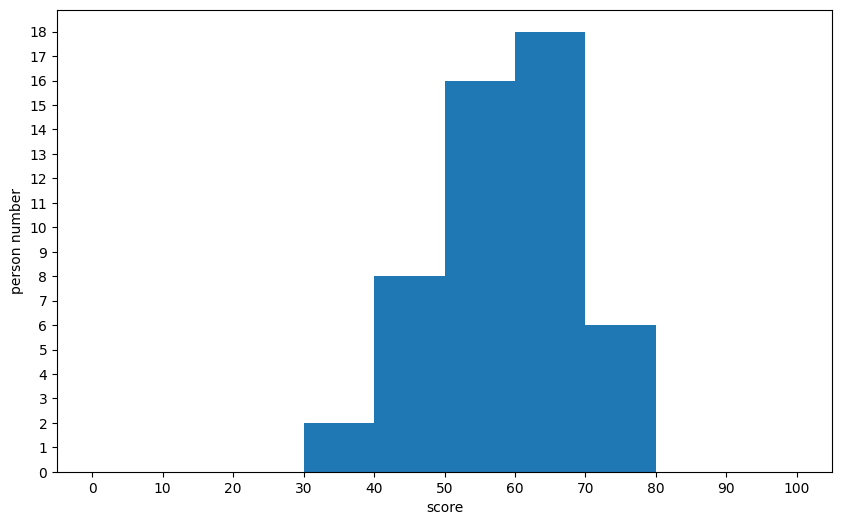

In [1184]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
freq, _, _ = ax.hist(eng_scores, bins=10, range=(0, 100))
ax.set_xlabel('score')
ax.set_ylabel('person number')
ax.set_xticks(np.linspace(0, 100, 10 + 1))
ax.set_yticks(np.arange(0, freq.max() + 1))
plt.show()

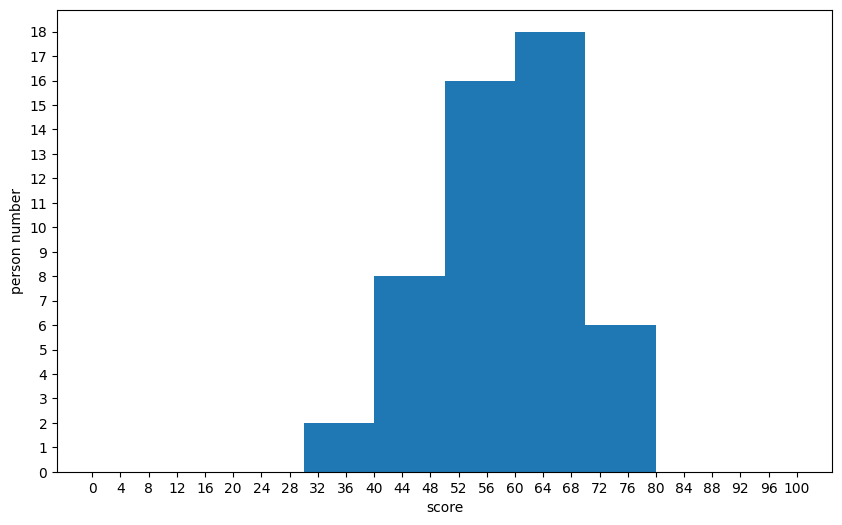

In [1185]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
freq, _, _ = ax.hist(eng_scores, bins=10, range=(0, 100))
ax.set_xlabel('score')
ax.set_ylabel('person number')
ax.set_xticks(np.linspace(0, 100, 25 + 1))
ax.set_yticks(np.arange(0, freq.max() + 1))
plt.show()

/tmp/ipykernel_44196/280964814.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(eng_scores, labels=['english'])


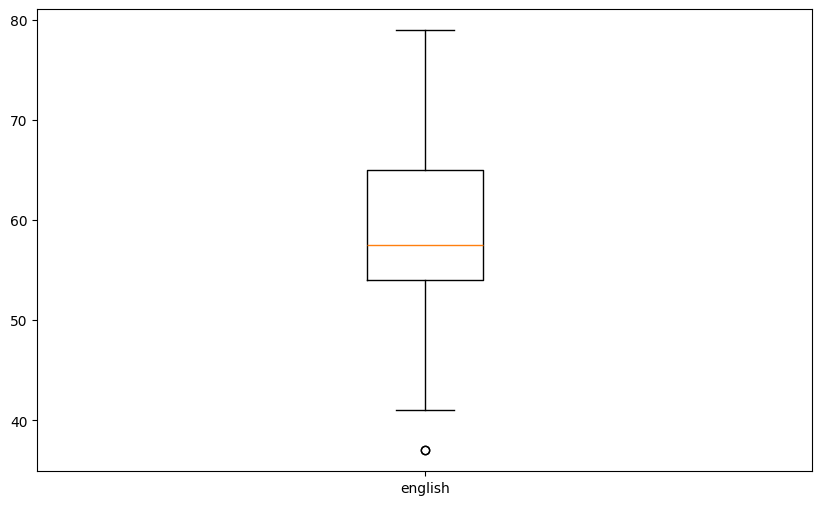

In [1186]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.boxplot(eng_scores, labels=['english'])
plt.show()

In [1187]:
df

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76
6,48,60
7,65,81
8,49,66
9,65,78


In [1188]:
scores_df

,score
student,
A,42
B,69
C,56
D,41
E,57
F,48
G,65
H,49
I,65


In [1189]:
en_scores = np.array(df['english'])[:10]
ma_scores = np.array(df['mathematics'])[:10]
scores_df = pd.DataFrame({'english':en_scores, 'mathematics':ma_scores},
                         index=pd.Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'], name='student'))

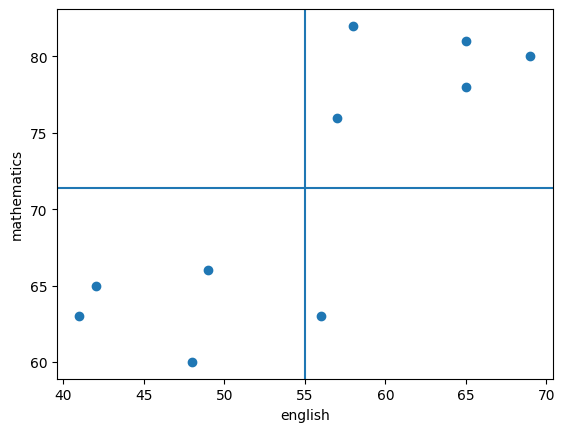

In [1190]:
plt.plot(scores_df.english, scores_df.mathematics, 'o')
plt.xlabel('english')
plt.ylabel('mathematics')
ax=plt.gca()
ax.axvline(scores_df.english.mean())
ax.axhline(scores_df.mathematics.mean())
plt.show()

In [1191]:
# 공분산
summary_df = scores_df.copy()

In [1192]:
summary_df

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63
D,41,63
E,57,76
F,48,60
G,65,81
H,49,66
I,65,78


In [1193]:
summary_df['english_deviation'] = summary_df.english - summary_df.english.mean()
summary_df['mathematics_deviation'] = summary_df['mathematics'] - summary_df['mathematics'].mean()
summary_df['product of deviation'] = summary_df['english_deviation'] * summary_df['mathematics_deviation'] # 두 편차 곱
summary_df

,english,mathematics,english_deviation,mathematics_deviation,product of deviation
student,,,,,
A,42,65,-13.0,-6.4,83.2
B,69,80,14.0,8.6,120.4
C,56,63,1.0,-8.4,-8.4
D,41,63,-14.0,-8.4,117.6
E,57,76,2.0,4.6,9.2
F,48,60,-7.0,-11.4,79.8
G,65,81,10.0,9.6,96.0
H,49,66,-6.0,-5.4,32.4
I,65,78,10.0,6.6,66.0


In [1194]:
summary_df['product of deviation'].mean() # 공분산 값

np.float64(62.8)

In [1195]:
np.cov(en_scores, ma_scores, ddof=0) # 영영의 공분산, 수영의 공분산, 영수의 공분산, 수수의 공분산

array([[86.  , 62.8 ],
       [62.8 , 68.44]])

# 상관계수

상관계수는 공분산을 각 데이터의 표준편차로 나누어 단위에 의존하지 않음

In [1196]:
np.cov(en_scores, ma_scores, ddof=0)[0, 1]

np.float64(62.800000000000004)

In [1197]:
np.cov(en_scores, ma_scores, ddof=0)[0, 1] / (en_scores.std() * ma_scores.std())

np.float64(0.8185692341186713)

In [1198]:
np.corrcoef(en_scores, ma_scores)

array([[1.   , 0.819],
       [0.819, 1.   ]])

In [1199]:
scores_df.corr()

,english,mathematics
english,1.000,0.819
mathematics,0.819,1.000


In [1200]:
poly_fit = np.polyfit(en_scores, ma_scores, 1)

In [1201]:
poly_1d = np.poly1d(poly_fit)

In [1202]:
poly_1d

poly1d([ 0.73 , 31.237])

In [1203]:
xs = np.linspace(en_scores.min(), en_scores.max())

In [1204]:
ys = poly_1d(xs)

In [1205]:
poly_fit[1], poly_fit[0]

(np.float64(31.23720930232561), np.float64(0.7302325581395342))

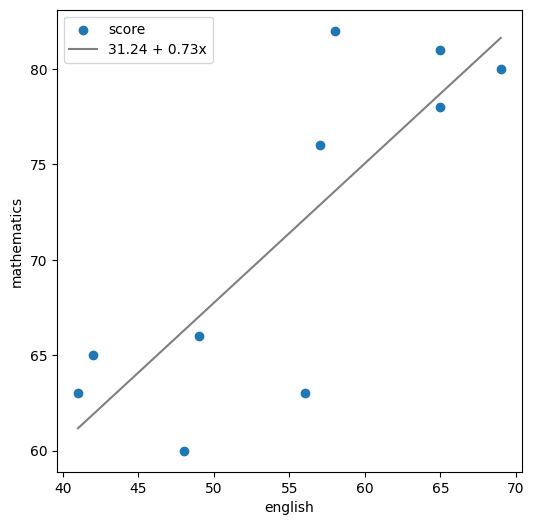

In [1206]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
ax.set_xlabel('english')
ax.set_ylabel('mathematics')
ax.scatter(en_scores, ma_scores, label='score')
ax.plot(xs, ys, color='gray', label=f'{poly_fit[1]:.2f} + {poly_fit[0]:.2f}x')
ax.legend(loc='upper left')
plt.show()

In [1207]:
ls ./drive/MyDrive/data/*npy

./drive/MyDrive/data/ch3_anscombe.npy


In [1208]:
anscombe_data = np.load('./drive/MyDrive/data/ch3_anscombe.npy')

In [1209]:
anscombe_data[0]

array([[10.  ,  8.04],
       [ 8.  ,  6.95],
       [13.  ,  7.58],
       [ 9.  ,  8.81],
       [11.  ,  8.33],
       [14.  ,  9.96],
       [ 6.  ,  7.24],
       [ 4.  ,  4.26],
       [12.  , 10.84],
       [ 7.  ,  4.82],
       [ 5.  ,  5.68]])

In [1210]:
anscombe_data.shape

(4, 11, 2)

In [1211]:
stats_df = pd.DataFrame(index=['X_mean', 'X_variance', 'Y_mean',
                               'Y_variance', 'X&Y_correlation', 'X&Y_regression_line'])

In [1212]:
stats_df

""
X_mean
X_variance
Y_mean
Y_variance
X&Y_correlation
X&Y_regression_line


In [1213]:
anscombe_data

array([[[10.  ,  8.04],
        [ 8.  ,  6.95],
        [13.  ,  7.58],
        [ 9.  ,  8.81],
        [11.  ,  8.33],
        [14.  ,  9.96],
        [ 6.  ,  7.24],
        [ 4.  ,  4.26],
        [12.  , 10.84],
        [ 7.  ,  4.82],
        [ 5.  ,  5.68]],

       [[10.  ,  9.14],
        [ 8.  ,  8.14],
        [13.  ,  8.74],
        [ 9.  ,  8.77],
        [11.  ,  9.26],
        [14.  ,  8.1 ],
        [ 6.  ,  6.13],
        [ 4.  ,  3.1 ],
        [12.  ,  9.13],
        [ 7.  ,  7.26],
        [ 5.  ,  4.74]],

       [[10.  ,  7.46],
        [ 8.  ,  6.77],
        [13.  , 12.74],
        [ 9.  ,  7.11],
        [11.  ,  7.81],
        [14.  ,  8.84],
        [ 6.  ,  6.08],
        [ 4.  ,  5.39],
        [12.  ,  8.15],
        [ 7.  ,  6.42],
        [ 5.  ,  5.73]],

       [[ 8.  ,  6.58],
        [ 8.  ,  5.76],
        [ 8.  ,  7.71],
        [ 8.  ,  8.84],
        [ 8.  ,  8.47],
        [ 8.  ,  7.04],
        [ 8.  ,  5.25],
        [19.  , 12.5 ],
        [ 

In [1214]:
for i, data in enumerate(anscombe_data):
    dataX = data[:, 0]
    dataY = data[:, 1]
    # print(dataX, dataY)
    poly_fit = np.polyfit(dataX, dataY, 1)
    stats_df[f'data{i+1}'] = [
        f'{np.mean(dataX):.2f}',
        f'{np.var(dataX):.2f}',
        f'{np.mean(dataY):.2f}',
        f'{np.var(dataY):.2f}',
        f'{np.corrcoef(dataX, dataY)[0, 1]:.2f}',
        f'{poly_fit[1]:.2f}+{poly_fit[0]:.2f}x']
stats_df

,data1,data2,data3,data4
X_mean,9.00,9.00,9.00,9.00
X_variance,10.00,10.00,10.00,10.00
Y_mean,7.50,7.50,7.50,7.50
Y_variance,3.75,3.75,3.75,3.75
X&Y_correlation,0.82,0.82,0.82,0.82
X&Y_regression_line,3.00+0.50x,3.00+0.50x,3.00+0.50x,3.00+0.50x


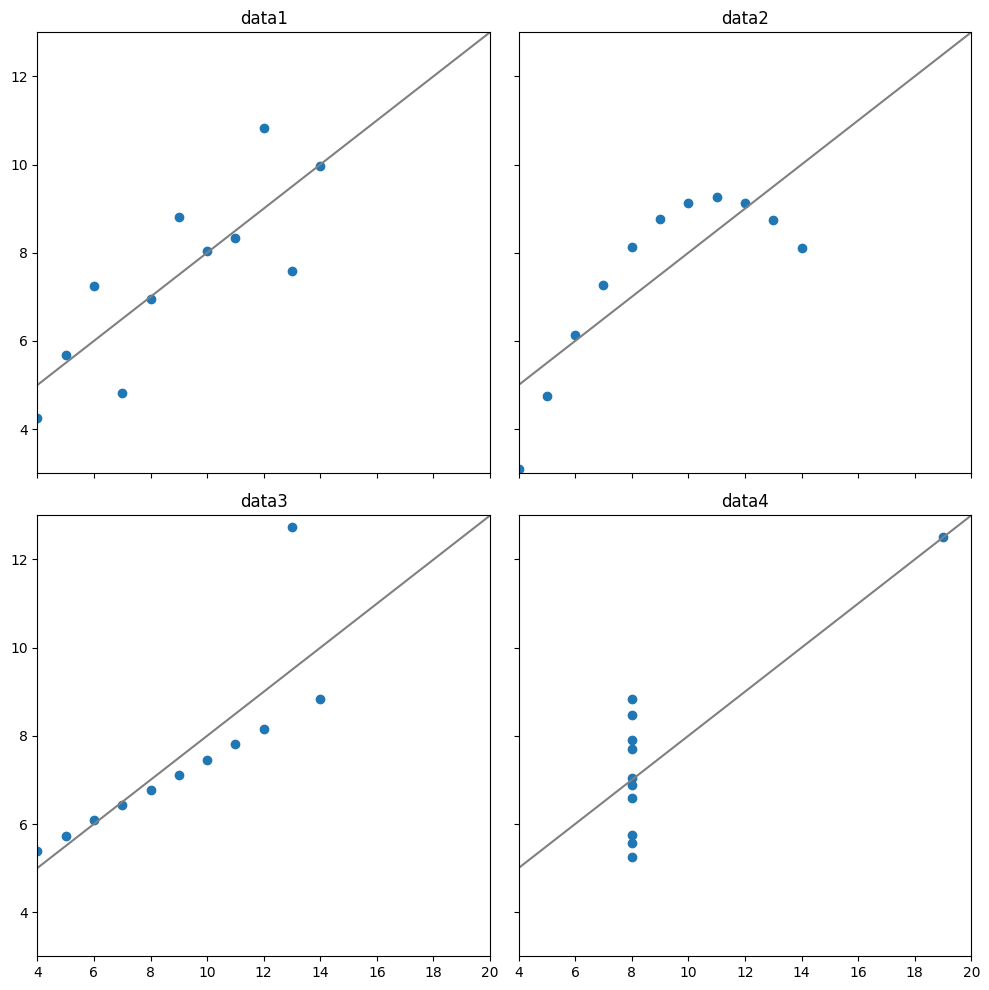

In [1215]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10),
                         sharex=True, sharey=True)
xs = np.linspace(0, 30, 100)
for i, data in enumerate(anscombe_data):
    poly_fit = np.polyfit(data[:,0], data[:,1], 1)
    poly_1d = np.poly1d(poly_fit)
    ys = poly_1d(xs)
    ax = axes[i//2, i%2]
    ax.set_xlim([4, 20])
    ax.set_ylim([3, 13])
    ax.set_title(f'data{i+1}')
    ax.scatter(data[:,0], data[:,1])
    ax.plot(xs, ys, color='gray')

plt.tight_layout()
plt.show()

모집단
: 통계분석 방법을 적용할 관심 대상의 전체 집합

표본
: 모집단에서 선택된 모집단 구성단위의 일부

전수조사 표본조사

모수
: 모집단의 특성을 나타내는 수치

통계량
: 표본의 특성을 나타내는 수치

In [1216]:
ls ./drive/MyDrive/data/*csv

./drive/MyDrive/data/air-passengers.csv
./drive/MyDrive/data/auto-mpg.csv
./drive/MyDrive/data/CCTV_Seoul.csv
./drive/MyDrive/data/ch2_scores_em.csv
./drive/MyDrive/data/ch4_scores400.csv
./drive/MyDrive/data/matplotlib_plot_data.csv
./drive/MyDrive/data/seoul_cctv.csv
./drive/MyDrive/data/stock-data.csv
./drive/MyDrive/data/stock_name_code_ChangePrice.csv
./drive/MyDrive/data/stock_px_2.csv


In [1217]:
df = pd.read_csv('./drive/MyDrive/data/ch4_scores400.csv')

In [1218]:
scores = np.array(df['score'])
scores[:10]

array([76, 55, 80, 80, 74, 61, 81, 76, 23, 80])

In [1219]:
len(scores)

400

In [1220]:
scores

array([ 76,  55,  80,  80,  74,  61,  81,  76,  23,  80,  41,  80,  68,
        88,  69,  57,  68,  86,  70,  68,  81,  73,  70,  90,  93,  79,
        66,  92,  88,  81,  52,  72,  59,  68,  74,  72,  63,  89,  45,
        81,  42,  76,  57,  83,  71,  74,  55,  60,  73,  79, 100,  73,
        85,  47,  50,  65,  52,  92,  64,  91,  92,  71,  78,  69,  78,
        77,  68,  78,  96,  81,  75,  72,  55,  55,  75,  49,  59,  89,
        99,  45,  94,  67,  70,  68,  86,  46,  77,  56,  79,  93,  70,
        76,  76,  58,  93,  96,  81,  71,  63,  61,  96,  91,  69,  46,
        28,  54,  68,  91,  60,  78,  90,  72,  68,  50,  52,  76,  67,
        72,  69,  80,  58,  65,  98,  58,  66,  61,  77,  85,  63,  64,
        66,  78,  59,  64,  34,  49,  68,  83,  74,  54,  49,  73,  45,
        86,  71,  46,  56,  59,  58,  48,  57,  60,  59,  87,  72,  55,
        65,  57,  65,  83,  74, 100,  76,  56,  82,  86,  86,  54,  68,
        87,  45,  63,  49,  56,  55,  89,  66,  57,  54,  72,  7

In [1221]:
mu = scores.mean()
mu

np.float64(69.53)

In [1222]:
for i in range(5):
    sample = np.random.choice(scores, 20)
    print(sample.mean())

72.4
72.1
64.65
71.05
65.4


In [1223]:
def sampling(data, n, loop):
    s_means = []
    for i in range(loop):
        sample = np.random.choice(data, n) # 무작위 20개 추출
        s_mean = sample.mean()
        s_means.append(s_mean)
    return s_means

In [1224]:
loop = 100
s_means = sampling(scores, 20, loop)
print(f"{loop}개의 평균: {np.mean(s_means)}")
print(f"{loop}개의 표준편차: {np.std(s_means)}")

100개의 평균: 69.29450000000001
100개의 표준편차: 3.0008490048651235


In [1225]:
loop = 1000
s_means = sampling(scores, 20, loop)
print(f"{loop}개의 평균: {np.mean(s_means)}")
print(f"{loop}개의 표준편차: {np.std(s_means)}")

1000개의 평균: 69.26920000000001
1000개의 표준편차: 3.322934149212109


In [1226]:
loop = 10000
s_means = sampling(scores, 50, loop)
print(f"{loop}개의 평균: {np.mean(s_means)}")
print(f"{loop}개의 표준편차: {np.std(s_means)}")

10000개의 평균: 69.51882799999998
10000개의 표준편차: 2.0166780175367607


In [1227]:
population = [1, 2, 3]
n = 2
s1 = [1, 1]
s2 = [1, 2]
s3 = [1, 3]
s4 = [2, 1]
s5 = [2, 2]
s6 = [2, 3]
s7 = [3, 1]
s8 = [3, 2]
s9 = [3, 3]

## 표본평균의 평균

가능한 모든 표본으로 이루어진 표본평균들의 평균은 모집단의 평균과 같다

In [1228]:
samples = np.array([s1, s2, s3, s4, s5, s6, s7, s8, s9])
sample_means = samples.mean(axis=1)
sample_means

array([1. , 1.5, 2. , 1.5, 2. , 2.5, 2. , 2.5, 3. ])

In [1229]:
# 평균
sample_means.mean()

np.float64(2.0)

In [1230]:
# 표준편차
sample_means.std()

np.float64(0.5773502691896257)

In [1231]:
# 모집단의 평균
np.mean(population)

np.float64(2.0)

In [1232]:
np.std(population)

np.float64(0.816496580927726)

In [1233]:
np.std(population) / np.sqrt(n)

np.float64(0.5773502691896257)

### 표본평균들의 표준편차는 모집단의 표준편차를 샘플수의 제곱근으로 나눈것과 같다.

# 확률의 기본

확률: 사건의 가능성을 수량화 하여 사건 A의 확률이라 한다.
- 동전 던지기에서 앞면이 나올 가능성
- 주식 투자에서 이득을 볼 가능성

확률변수
- 결과를 알아 맞힐 수는 없지만, 취하는 값과 그 값이 나올 확률이 결정되어 있는것
- 실험이나 관찰의 결과 값을 1:1 실수로 대응시키려는 함수

시행: 확률변수의 결과를 관측하는 것

실현값: 시행에 의해 관측되는 값

확률분포 - 확률변수가 취할 수 있는 모든 값에 대해 각각의 확률을 대응시킨 것

$$P(A) = \frac{n(A)}{N}$$

$$P(X = 1) = \frac{1}{6}$$

In [1234]:
dice = [1, 2, 3, 4, 5, 6]
prob = [1/21, 2/21, 3/21, 4/21, 5/21, 6/21]

In [1235]:
np.random.choice(dice, p=prob)

np.int64(3)

In [1236]:
sample = np.random.choice(dice, 100, p=prob)

In [1237]:
# 도수분포표 그려보기
freq, _ = np.histogram(sample, bins=6, range=(1, 7))
pd.DataFrame({'frequency': freq, 'relative_frequency':freq / 100}, index=pd.Index(np.arange(1, 7), name='dice')) # 100으로 나눈이유 상대도수의 정의가 전체 갯수분의 도수라서?

,frequency,relative_frequency
dice,,
1,4,0.04
2,8,0.08
3,11,0.11
4,15,0.15
5,33,0.33
6,29,0.29


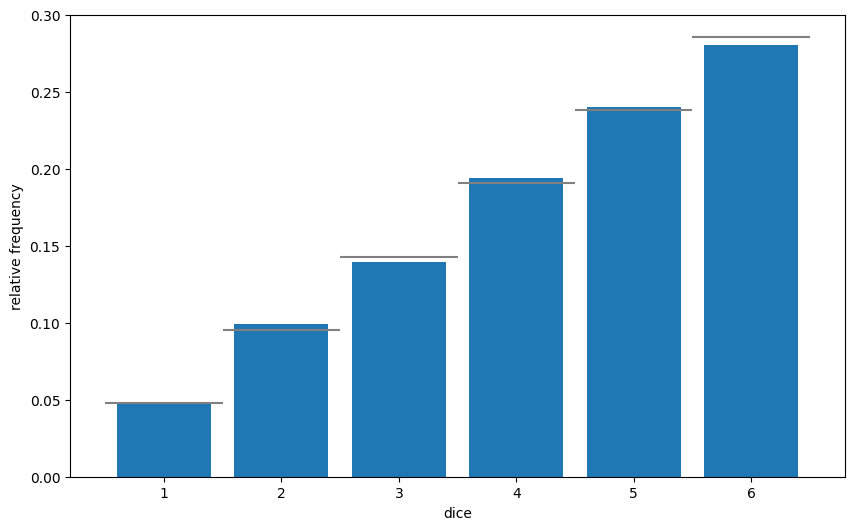

In [1238]:
sample = np.random.choice(dice, 10000, p=prob)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample, bins=6, range=(1, 7), density=True, rwidth=0.8)
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')
ax.set_xticks(np.linspace(1.5, 6.5, 6))
ax.set_xticklabels(np.arange(1, 7))
ax.set_xlabel('dice')
ax.set_ylabel('relative frequency')
plt.show()

In [1239]:
dice = [1, 2, 3, 4, 5, 6]
prob = [1/21, 2/21, 3/21, 4/21, 5/21, 6/21]

In [1240]:
x_set = np.array([1, 2, 3, 4, 5, 6])

In [1241]:
def f(x):
    if x in x_set:
        return x / 21
    else:
        return 0

In [1242]:
X = [x_set, f]

In [1243]:
X

[array([1, 2, 3, 4, 5, 6]), <function __main__.f(x)>]

In [1244]:
prob = np.array([f(x_k) for x_k in x_set])

In [1245]:
prob

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

In [1246]:
dict(zip(x_set, prob))

{np.int64(1): np.float64(0.047619047619047616),
 np.int64(2): np.float64(0.09523809523809523),
 np.int64(3): np.float64(0.14285714285714285),
 np.int64(4): np.float64(0.19047619047619047),
 np.int64(5): np.float64(0.23809523809523808),
 np.int64(6): np.float64(0.2857142857142857)}

<BarContainer object of 6 artists>

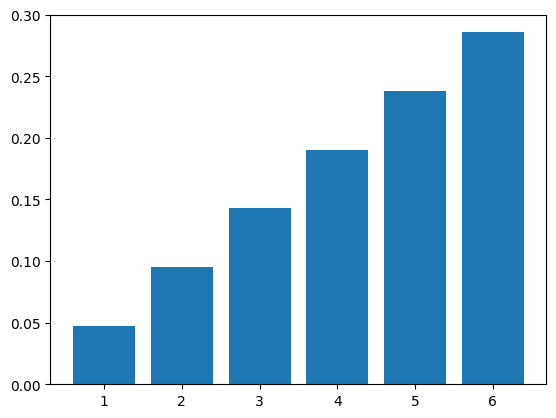

In [1247]:
plt.bar(x_set, prob)

# 확률의 성질

$$f(x_k) \ge 0 $$

$$ \sum_k f(x_k) = 1 $$

In [1248]:
np.all(prob >= 0)

np.True_

In [1249]:
np.sum(prob)

np.float64(0.9999999999999999)

# 누적분포함수

$$F(x) = P(X \le x) = \sum_{x_k \le x} f(x_k)$$

In [1250]:
def F(x):
    return np.sum([f(x_k) for x_k in x_set if x_k <= x])

In [1251]:
F(3)

np.float64(0.2857142857142857)

몬테카를로 시뮬레이션

- 난수를 이용해 프로그램적으로 문제를 해결함

In [1252]:
import random

In [1253]:
data_list = range(1, 46)

In [1254]:
data_list

range(1, 46)

In [1255]:
random.sample(data_list, 6)

[44, 20, 2, 9, 28, 41]

In [1256]:
random.choice(data_list)

39

In [1257]:
raffle_list=[]
for i in range(10000):
    raffle_number = random.sample(data_list, 6)
    raffle_list.append(raffle_number)

In [1258]:
len(raffle_list)

10000

In [1259]:
raffle_list[:3]

[[13, 34, 8, 44, 36, 15], [25, 38, 1, 39, 24, 21], [15, 43, 44, 25, 27, 14]]

In [1260]:
random.choice(raffle_list)

[34, 44, 10, 21, 17, 39]